# Baselines — Statistical / Simple Imputation (Sensor Time Series)
This notebook is a sectioned version of `baselines/baseline-stat.py`.

**Assumptions**
- `../data.txt` exists (or `data.txt` if you run from the repo root).
- You have `numpy`, `pandas`, `scipy`, and `matplotlib` installed.

**Notes**
- This baseline notebook uses the same *random missingness mask* and forced boundary missingness as the script.
- It does **not** include the outlier-masking step used in the LSTM-VAE notebook unless you add it explicitly.

In [32]:
# === Section: Imports ===
import numpy as np
import pandas as pd
from scipy.stats import mode
import matplotlib.pyplot as plt

In [34]:
# New Dataset https://www.kaggle.com/datasets/olaflundstrom/sensor-data/code
DATASET = '../data/dataset1.csv'
df = pd.read_csv(DATASET)
df.sort_values('datetime', inplace=True)
df.set_index('datetime', inplace=True)
temperature_series = df['temperature'].astype(float)
data = temperature_series.values
N = len(data)
print("Loaded dataset with shape:", df.shape)
print(f"Loaded {N} temperature readings.")

Loaded dataset with shape: (26387, 2)
Loaded 26387 temperature readings.


In [35]:
# === Section: Missingness Masks ===
# Build one mask per requested missingness pattern so each case is evaluated separately.
missing_rate = 0.3
missing_positions = ['START', 'MIDDLE', 'END', 'RANDOM']
missing_count = max(1, int(round(N * missing_rate)))

def build_missing_mask(position):
    mask = np.ones(N, dtype=bool)

    if position == 'START':
        mask[:missing_count] = False
    elif position == 'MIDDLE':
        start = max(0, (N - missing_count) // 2)
        end = start + missing_count
        mask[start:end] = False
    elif position == 'END':
        mask[-missing_count:] = False
    elif position == 'RANDOM':
        rng = np.random.default_rng(42)
        missing_indices = rng.choice(N, size=missing_count, replace=False)
        mask[missing_indices] = False
    else:
        raise ValueError(f'Unknown missing position: {position}')

    return mask

missing_masks = {position: build_missing_mask(position) for position in missing_positions}

for position, mask in missing_masks.items():
    masked_points = (~mask).sum()
    print(f'{position:<7} masked points: {masked_points} / {N} ({masked_points / N * 100:.1f}%)')

START   masked points: 7916 / 26387 (30.0%)
MIDDLE  masked points: 7916 / 26387 (30.0%)
END     masked points: 7916 / 26387 (30.0%)
RANDOM  masked points: 7916 / 26387 (30.0%)


In [36]:
# === Section: Baseline Imputation Methods ===
baseline_labels = ['Mean', 'Median', 'Mode', 'Random', 'LOCF', 'LOCB', 'Hot-deck', 'Forward Fill', 'Linear Interp']

def score_imputation(predicted, missing_true):
    return {
        'MAE': float(np.mean(np.abs(predicted - missing_true))),
        'RMSE': float(np.sqrt(np.mean((predicted - missing_true) ** 2)))
    }

def evaluate_missing_mask(mask):
    missing_true = data[~mask]
    observed = data[mask]

    if observed.size == 0:
        raise RuntimeError('No observed points available for imputation.')

    imputations = {}
    metrics = {}

    mean_value = observed.mean()
    mean_imputed = data.copy().astype(float)
    mean_imputed[~mask] = mean_value
    imputations['Mean'] = mean_imputed
    metrics['Mean'] = score_imputation(mean_imputed[~mask], missing_true)

    median_value = np.median(observed)
    median_imputed = data.copy().astype(float)
    median_imputed[~mask] = median_value
    imputations['Median'] = median_imputed
    metrics['Median'] = score_imputation(median_imputed[~mask], missing_true)

    mode_value = mode(observed, keepdims=True).mode[0]
    mode_imputed = data.copy().astype(float)
    mode_imputed[~mask] = mode_value
    imputations['Mode'] = mode_imputed
    metrics['Mode'] = score_imputation(mode_imputed[~mask], missing_true)

    rng = np.random.default_rng(42)
    random_imputed = data.copy().astype(float)
    random_imputed[~mask] = rng.choice(observed, size=(~mask).sum(), replace=True)
    imputations['Random'] = random_imputed
    metrics['Random'] = score_imputation(random_imputed[~mask], missing_true)

    locf_imputed = data.copy().astype(float)
    locf_imputed[~mask] = np.nan
    locf_imputed = pd.Series(locf_imputed, index=df.index).ffill().bfill().values
    imputations['LOCF'] = locf_imputed
    metrics['LOCF'] = score_imputation(locf_imputed[~mask], missing_true)

    locb_imputed = data.copy().astype(float)
    locb_imputed[~mask] = np.nan
    locb_imputed = pd.Series(locb_imputed, index=df.index).bfill().ffill().values
    imputations['LOCB'] = locb_imputed
    metrics['LOCB'] = score_imputation(locb_imputed[~mask], missing_true)

    donor_pool = observed
    hotdeck_imputed = data.copy().astype(float)
    hotdeck_imputed[~mask] = rng.choice(donor_pool, size=(~mask).sum(), replace=True)
    imputations['Hot-deck'] = hotdeck_imputed
    metrics['Hot-deck'] = score_imputation(hotdeck_imputed[~mask], missing_true)

    ffill_imputed = data.copy().astype(float)
    ffill_imputed[~mask] = np.nan
    ffill_imputed = pd.Series(ffill_imputed, index=df.index).ffill().bfill().values
    imputations['Forward Fill'] = ffill_imputed
    metrics['Forward Fill'] = score_imputation(ffill_imputed[~mask], missing_true)

    interp_imputed = data.copy().astype(float)
    interp_imputed[~mask] = np.nan
    interp_imputed = (
        pd.Series(interp_imputed, index=df.index)
        .interpolate(method='linear')
        .bfill()
        .ffill()
        .values
    )
    imputations['Linear Interp'] = interp_imputed
    metrics['Linear Interp'] = score_imputation(interp_imputed[~mask], missing_true)

    return {
        'mask': mask,
        'missing_true': missing_true,
        'imputations': imputations,
        'metrics': metrics,
    }

results = {position: evaluate_missing_mask(mask) for position, mask in missing_masks.items()}

for position in missing_positions:
    print(f'\n{position} missingness')
    for label in baseline_labels:
        metric = results[position]['metrics'][label]
        print(f'  {label:<13} MAE: {metric["MAE"]:.4f}, RMSE: {metric["RMSE"]:.4f}')


START missingness
  Mean          MAE: 9.2347, RMSE: 11.5840
  Median        MAE: 9.1957, RMSE: 11.8297
  Mode          MAE: 11.0104, RMSE: 14.3724
  Random        MAE: 10.8356, RMSE: 13.7920
  LOCF          MAE: 13.6231, RMSE: 16.7863
  LOCB          MAE: 13.6231, RMSE: 16.7863
  Hot-deck      MAE: 10.9410, RMSE: 13.8456
  Forward Fill  MAE: 13.6231, RMSE: 16.7863
  Linear Interp MAE: 13.6231, RMSE: 16.7863

MIDDLE missingness
  Mean          MAE: 7.0395, RMSE: 7.9770
  Median        MAE: 6.6843, RMSE: 7.8048
  Mode          MAE: 6.2012, RMSE: 7.8215
  Random        MAE: 9.5952, RMSE: 12.2936
  LOCF          MAE: 11.7102, RMSE: 14.0247
  LOCB          MAE: 12.7757, RMSE: 14.4487
  Hot-deck      MAE: 9.6596, RMSE: 12.2230
  Forward Fill  MAE: 11.7102, RMSE: 14.0247
  Linear Interp MAE: 4.6072, RMSE: 5.5114

END missingness
  Mean          MAE: 5.8609, RMSE: 6.9491
  Median        MAE: 6.3201, RMSE: 7.5575
  Mode          MAE: 8.3491, RMSE: 10.2349
  Random        MAE: 9.5612, RMSE: 11

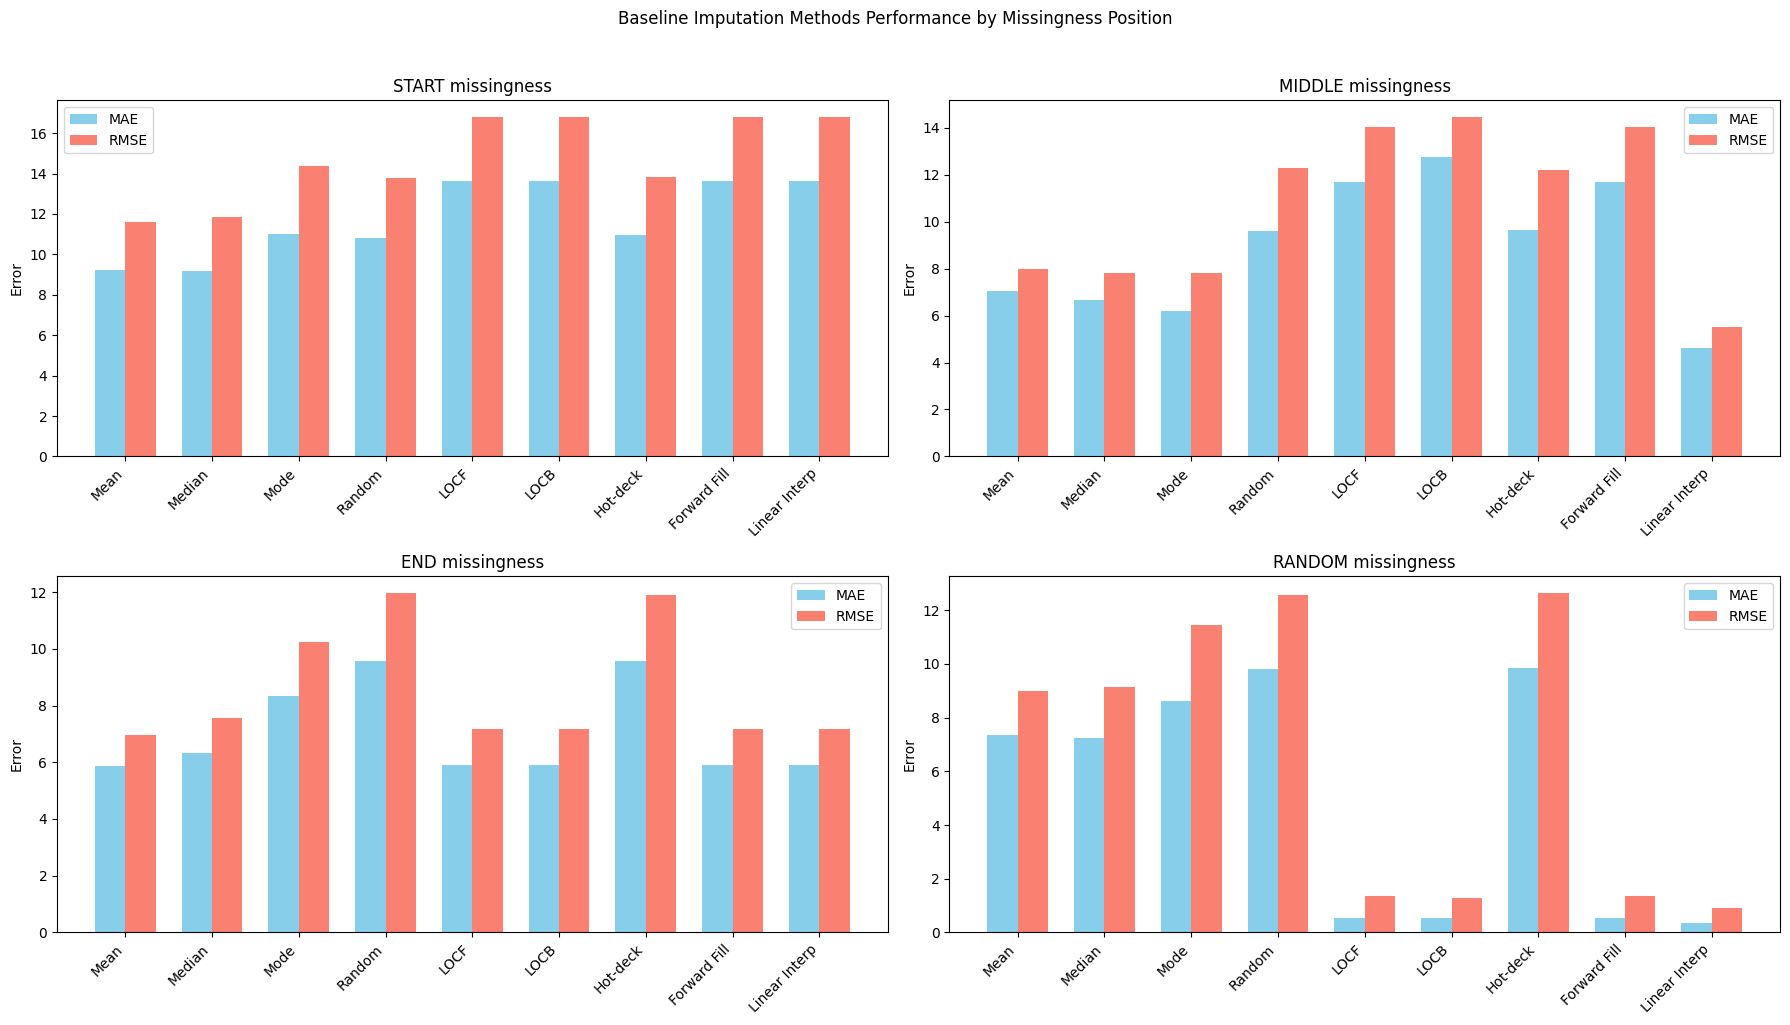

In [37]:
# === Plotting both MAE and RMSE for all baselines ===
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=False)
axes = axes.flatten()

for ax, position in zip(axes, missing_positions):
    metrics = results[position]['metrics']
    mae_values = [metrics[label]['MAE'] for label in baseline_labels]
    rmse_values = [metrics[label]['RMSE'] for label in baseline_labels]
    x = np.arange(len(baseline_labels))
    width = 0.35

    ax.bar(x - width / 2, mae_values, width, label='MAE', color='skyblue')
    ax.bar(x + width / 2, rmse_values, width, label='RMSE', color='salmon')
    ax.set_xticks(x)
    ax.set_xticklabels(baseline_labels, rotation=45, ha='right')
    ax.set_ylabel('Error')
    ax.set_title(f'{position} missingness')
    ax.legend()

fig.suptitle('Baseline Imputation Methods Performance by Missingness Position', y=1.02)
fig.tight_layout()
plt.show()

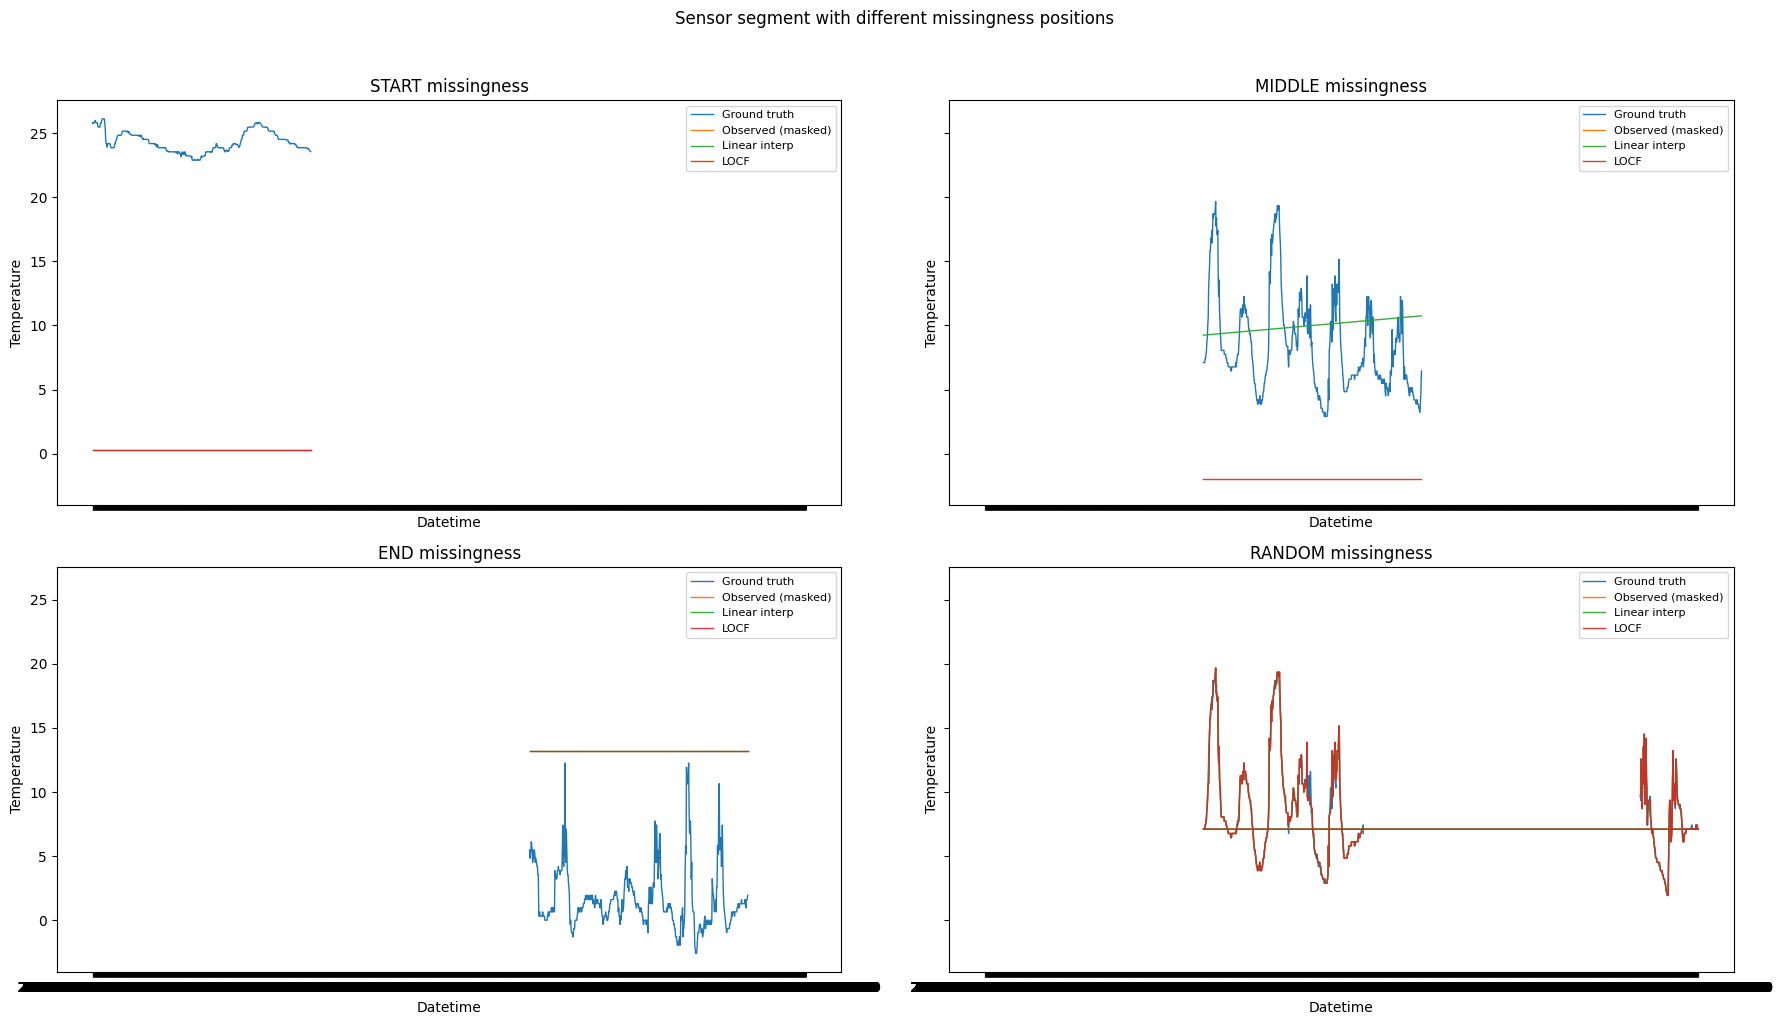

In [38]:
# === Section: Visual Check (Optional) ===
# Plot a representative segment for each missingness position so the layout of missing points is visible.

segment_len = min(500, N)

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, position in zip(axes, missing_positions):
    mask = results[position]['mask']
    imputations = results[position]['imputations']

    if position == 'START':
        segment_start = 0
    elif position == 'MIDDLE':
        segment_start = max(0, (N - segment_len) // 2)
    elif position == 'END':
        segment_start = max(0, N - segment_len)
    else:
        missing_indices = np.flatnonzero(~mask)
        if missing_indices.size:
            center_index = int(np.median(missing_indices))
            segment_start = max(0, center_index - segment_len // 2)
            segment_start = min(segment_start, max(0, N - segment_len))
        else:
            segment_start = 0

    segment_end = min(N, segment_start + segment_len)
    idx = df.index[segment_start:segment_end]

    observed_segment = data.copy().astype(float)
    observed_segment[~mask] = np.nan

    ax.plot(idx, data[segment_start:segment_end], label='Ground truth', linewidth=1)
    ax.plot(idx, observed_segment[segment_start:segment_end], label='Observed (masked)', linewidth=1)
    ax.plot(idx, imputations['Linear Interp'][segment_start:segment_end], label='Linear interp', linewidth=1, alpha=0.9)
    ax.plot(idx, imputations['LOCF'][segment_start:segment_end], label='LOCF', linewidth=1, alpha=0.9)

    ax.set_title(f'{position} missingness')
    ax.set_xlabel('Datetime')
    ax.set_ylabel('Temperature')
    ax.legend(fontsize=8)

fig.suptitle('Sensor segment with different missingness positions', y=1.02)
fig.tight_layout()
plt.show()